<a href="https://colab.research.google.com/github/mitparekh8263/CV-2026-H11/blob/main/Practical_04/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('/content/tiger.jpg', cv2.IMREAD_GRAYSCALE)
img.shape

(364, 549)

In [3]:
def add_gaussian_noise(img, mean=0, sigma=50):
  noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
  noisy_img = img.astype(np.float32) + noise
  noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
  return noisy_img

In [4]:
noisy_img = add_gaussian_noise(img)

In [5]:
filtered_img_inbuilt = cv2.GaussianBlur(noisy_img, ksize=(3, 3), sigmaX=0)

In [6]:
def gaussian_filter_vectorized(img, kernel_size=3, sigma=50):
  radius = kernel_size // 2
  ax = np.arange(-radius, radius + 1, dtype=np.float32)
  x, y = np.meshgrid(ax, ax)

  const = 1 / (2 * np.pi * (sigma**2))
  exp = np.exp(-(x**2 + y**2) / (2 * (sigma**2)))
  G = const * exp
  G = G / np.sum(G)

  return cv2.filter2D(img, -1, G)

filtered_img_vectorized = gaussian_filter_vectorized(noisy_img, kernel_size=3, sigma=50)

In [7]:
def gaussian_filter_manual(image, kernel_size=7, sigma=2):
    k = kernel_size // 2

    # Create Gaussian kernel using mgrid representation
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)

    # Padding the edges to handle boundaries safely
    padded = np.pad(image, ((k, k), (k, k)), mode='edge')

    out_h, out_w = image.shape
    filtered = np.zeros((out_h, out_w), dtype=np.float32)

    # Manual Convolution nested loops
    for i in range(out_h):
        for j in range(out_w):
            region = padded[i:i + kernel_size, j:j + kernel_size]
            filtered[i, j] = np.sum(region * kernel)

    return np.clip(filtered, 0, 255).astype(np.uint8)

filtered_img_manual = gaussian_filter_manual(noisy_img, kernel_size=7, sigma=2)

In [8]:
def edge_detection_filter(img):
    kernel = np.array([[-1, -2, 1],
                       [0, 0, 0],
                       [1, 2, 1]], dtype=np.float32)
    return cv2.filter2D(img, -1, kernel)

filtered_img_edge = edge_detection_filter(noisy_img)

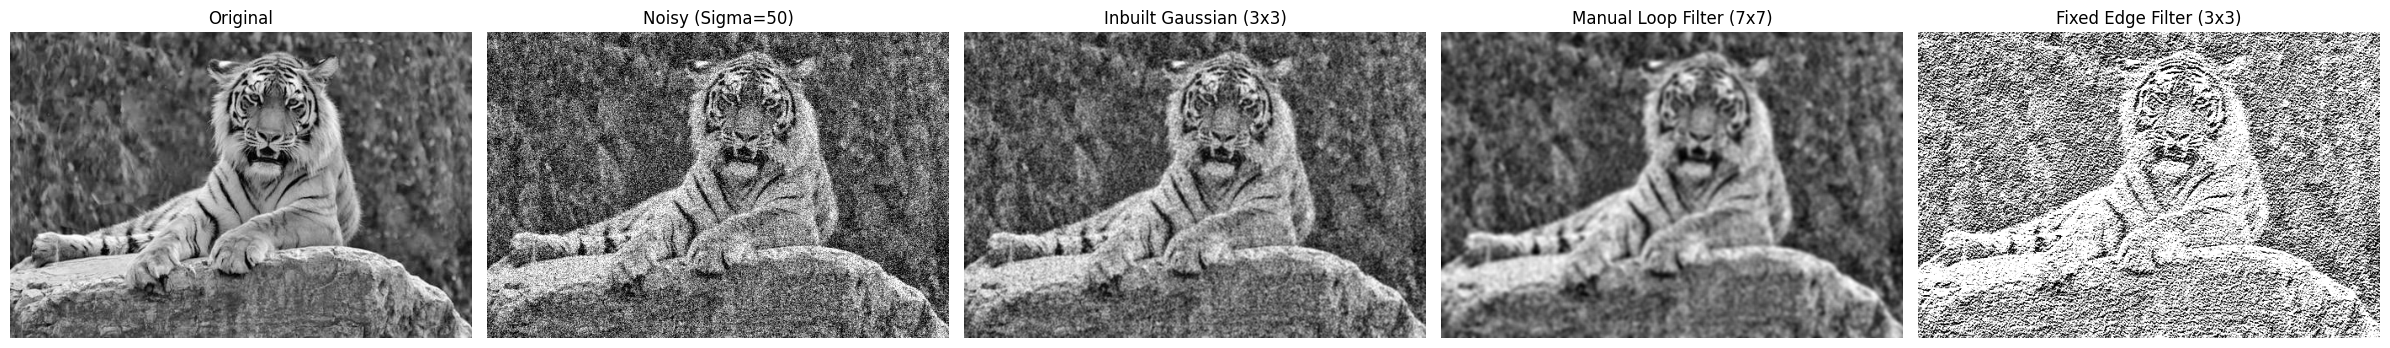

In [9]:
sigma = 50
plt.figure(figsize=(24, 5))

# Plot 1: Original
plt.subplot(1, 5, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

# Plot 2: Noisy
plt.subplot(1, 5, 2)
plt.title(f"Noisy (Sigma={sigma})")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

# Plot 3: Inbuilt OpenCV Filter
plt.subplot(1, 5, 3)
plt.title("Inbuilt Gaussian (3x3)")
plt.imshow(filtered_img_inbuilt, cmap='gray')
plt.axis('off')

# Plot 4: User-Defined Loop Filter
plt.subplot(1, 5, 4)
plt.title("Manual Loop Filter (7x7)")
plt.imshow(filtered_img_manual, cmap='gray')
plt.axis('off')

# Plot 5: Fixed Pre-defined Kernel
plt.subplot(1, 5, 5)
plt.title("Fixed Edge Filter (3x3)")
plt.imshow(filtered_img_edge, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()